# MS-Spectral-Foundation: Real-Data Tutorial

## Tutorial Goal & Biological Question

This tutorial applies the **MS-Spectral-Foundation** self-supervised representation-learning pipeline to real clinical serum LC-MS/MS data, addressing the following biological question (as stated in the project design documents):

> **Can self-supervised spectrum embeddings learned from serum LC-MS/MS data reveal meaningful distribution-level differences between cirrhosis and HCC samples?**

The goal is **not** to build a fully supervised disease classifier, but to evaluate whether the learned embedding space captures biologically relevant molecular structure that differs between these two disease conditions.

Hepatocellular carcinoma (HCC) is a primary liver cancer that almost always arises on a background of cirrhosis. The two conditions share overlapping serum protein profiles, making their distinction challenging by conventional means. By learning general-purpose spectrum representations via BERT-style self-supervised pre-training — with no peptide identification or disease labels — the model can be evaluated on whether its embeddings carry group-discriminative information.

### Pipeline Overview

| Step | Script | Modules |
|------|--------|---------|
| 1. Self-supervised training | `train.py` → `main()` | 1 (parse) · 2 (filter) · 3 (bin) · 4–6 (SSL model) |
| 2. Embedding analysis | `run_embedding_analysis.py` → `main()` | 6 (embeddings) · 7 (distribution) · 8 (evaluation) |

**To run on a different dataset:** change the MGF paths and model path in Section 3 (Configuration).

## Section 1: Dataset Overview

## Dataset Description

### Source

PRIDE archive project **[PXD047546](https://www.ebi.ac.uk/pride/archive/projects/PXD047546)** — a serum LC-MS/MS cohort comparing patients with **liver cirrhosis** (control group) and patients with **hepatocellular carcinoma (HCC)** arising on a cirrhotic background.

### Data Overview

The actual input to this project consists of raw LC-MS/MS mass spectrum files (`.raw`) and derived chromatogram files (`.mzML` / `.mgf`). The remaining `.txt` / `.fasta` files are used for grouping, validation, or comparison with results from the original paper, but are **not** direct inputs to the self-supervised model.

| Property | Details |
|----------|---------|
| Total raw files | 10 (5 Cirrhosis + 5 HCC) |
| Sample type | Human serum |
| Raw file size | ~2–5 GB each |
| Direct model input | MGF (Mascot Generic Format) |

### All 10 Raw Files by Name

**Cirrhotic samples (control):**

| File |
|------|
| `09062023_Mehta_GR10000524_DDRC_Sample1_480_cirrhotic.raw` |
| `09062023_Mehta_GR10000524_DDRC_Sample2_491_cirrhotic.raw` |
| `09062023_Mehta_GR10000524_DDRC_Sample3_554_cirrhotic.raw` |
| `09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic.raw` |
| `09062023_Mehta_GR10000524_DDRC_Sample5_654_cirrhotic.raw` |

**HCC samples (case):**

| File |
|------|
| `09062023_Mehta_GR10000524_DDRC_Sample6_0121_HCC.raw` |
| `09062023_Mehta_GR10000524_DDRC_Sample7_0187_HCC.raw` |
| `09062023_Mehta_GR10000524_DDRC_Sample8_0203_HCC.raw` |
| `09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC.raw` |
| `09062023_Mehta_GR10000524_DDRC_Sample10_0543_HCC.raw` |

Raw files contain full MS1 scans, MS/MS (MS2) scans, and instrument metadata (scan numbers, scan types, retention time per scan).

### Sample Structure — Important Distinction

- **One raw file = one biological sample (one patient serum sample)**
- **One raw file contains thousands to hundreds of thousands of MS/MS spectra**
- **Each MS/MS spectrum = one training instance for self-supervised learning**

Therefore:
- **Disease labels** (HCC vs. Cirrhosis) exist at the **sample level**
- **Model training** operates at the **spectrum level**

### Data Format Hierarchy

```
Disease group  (Cirrhosis / HCC)
└── Patient sample  (1 .raw file = 1 patient)
    └── Thousands of MS/MS spectra  (1 per "BEGIN IONS … END IONS" block)
        └── Each spectrum = set of (m/z, intensity) pairs
```

A spectrum can be regarded as: **Sequence / Set / Sparse / Signal** — and this is the representation the transformer operates on.

### Pre-processing Pipeline

```
.raw  ──(msconvert / ProteoWizard)──▶  .mzML  ──(pyteomics)──▶  .mgf  ──▶  Model Input
```

#### Stage 1 — `.raw` to `.mzML`
Vendor raw files are converted to the open `.mzML` format using **ProteoWizard (msconvert)**. The `.mzML` file retains:
- Complete MS1 and MS2 spectra
- m/z array and intensity array per spectrum
- Retention time per scan
- Precursor m/z and charge (for MS2 scans)
- Explicit separation of MS1 and MS2 scans

#### Stage 2 — `.mzML` to `.mgf`
MS2 spectra are extracted using **pyteomics** and serialised as MGF blocks:

```
BEGIN IONS
PEPMASS=912.4572
CHARGE=2+
RTINSECONDS=3601.23
208.0944 1234.5
304.1550 8901.2
...
END IONS
```

Each `BEGIN IONS … END IONS` block is one training instance.

### Files Used in This Tutorial

This tutorial uses **two full-size MGF files** (one per disease group) derived from the PRIDE dataset:

| File | Group |
|------|-------|
| `09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf` | Cirrhosis |
| `09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC_output.mgf` | HCC |

Each file is ~300–370 MB. They are **not** included in the repository due to GitHub file size limits.

#### Provided Example Data (for quick testing)

Truncated versions (~25 MB each) are included in `example_data/` and preserve realistic MS/MS spectrum structure. They are sufficient to run the full pipeline, train the model, and perform embedding analysis.

#### Two Usage Modes

| Mode | Description |
|------|-------------|
| **Option 1 — Full pipeline** | Use `example_data/*.mgf` → train from scratch → extract embeddings → analyse |
| **Option 2 — Fast demo** | Load pretrained `.pt` checkpoint + precomputed embedding cache → skip to analysis |

Precomputed resources (via Git LFS / Google Drive):
- Pretrained checkpoint: https://github.com/yuqianxu2816/MS-Spectral-Foundation/blob/main/outputs/model_ssl_v4_epoch019.pt
- Embedding cache (Google Drive — too large for GitHub): https://drive.google.com/drive/u/1/folders/1mou-54IODd5_r8QfB2PgUWHsQalbGsQP

## Section 2: Installation

### Requirements

- Python 3.9 – 3.12 (3.13 not yet recommended — some MS wheels are unavailable)
- PyTorch ≥ 2.0 (CPU-only is fine; GPU is optional but speeds up training)
- Git (to clone the repository)

### Step-by-step Installation

**1. Clone the repository**

```bash
git clone https://github.com/yuqianxu2816/MS-Spectral-Foundation.git
cd MS-Spectral-Foundation
```

**2. (Recommended) Create and activate a virtual environment**

```bash
# Using conda
conda create -n ms-found python=3.11
conda activate ms-found

# Or using venv
python -m venv .venv
# Windows:
.venv\Scripts\activate
# Linux/macOS:
source .venv/bin/activate
```

**3. Install PyTorch** (visit https://pytorch.org for your CUDA version)

```bash
# CPU-only example
pip install torch --index-url https://download.pytorch.org/whl/cpu
```

**4. Install the package and all dependencies**

```bash
pip install -e .
```

This installs `MS_Spectral_Foundation` as an editable package, along with all required libraries (`lightning`, `pyteomics`, `spectrum-utils`, `scikit-learn`, `matplotlib`, etc.).

---

### Real Dataset for This Tutorial

To apply the MS-Spectral-Foundation pipeline to a real biological question, the same PRIDE dataset **PXD047546** is used here, but now in the context of an actual downstream analysis rather than only an example demonstration.

The analysis is based on serum LC-MS/MS data derived from two biologically meaningful conditions:

- **cirrhosis**
- **hepatocellular carcinoma (HCC)**

This tutorial uses the **full** MGF files (not the truncated example data), specifically:

- `09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf`
- `09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC_output.mgf`

These are real spectra derived from the PRIDE dataset:  
https://www.ebi.ac.uk/pride/archive/projects/PXD047546

---

### Only Feasible Option — Fast Demo (Precomputed Outputs)

Running the full workflow on the real data is possible in principle, but in practice it is time-consuming. Training from scratch to produce the `.pt` checkpoint can take **more than 10 hours**, and embedding extraction on the full data also adds substantial runtime.

For convenience, the repository provides precomputed resources that allow you to skip training and embedding extraction entirely, and jump directly to downstream analysis:

- **Pretrained model checkpoint** (`.pt`, via Git LFS):  
  https://github.com/yuqianxu2816/MS-Spectral-Foundation/blob/main/outputs/model_ssl_v4_epoch019.pt

- **Precomputed embedding cache** (Google Drive — too large for GitHub):  
  https://drive.google.com/drive/u/1/folders/1mou-54IODd5_r8QfB2PgUWHsQalbGsQP

To pull the checkpoint if you have Git LFS installed:

```bash
git lfs pull
```

These allow users to:
- skip training
- skip embedding extraction
- directly run downstream analysis

---

The **next cell below** installs any missing Python packages automatically — safe to run inside an existing environment.

In [6]:
# ============================================================
# Dependency setup — safe for ALL environments (Anaconda, venv, plain Python)
#
# Strategy: check each package BEFORE trying to install it.
# Only missing packages are installed → already-installed C-extensions
# (numpy, pyarrow, etc.) are never upgraded while loaded → no kernel crash.
# ============================================================
import importlib.util, subprocess, sys

# Map: importable module name → pip install name
_packages = {
    "lightning"        : "lightning",
    "pytorch_lightning": "pytorch-lightning",
    "selfies"          : "selfies>=2.1.1",
    "pyteomics"        : "pyteomics>=4.7.2",
    "rdkit"            : "rdkit",
    "spectrum_utils"   : "spectrum-utils>=0.4.1",
    "PIL"              : "pillow>=9.4.0",
    "einops"           : "einops>=0.4.1",
    "lance"            : "lance",
    "polars"           : "polars>=0.19.0",
    "pyarrow"          : "pyarrow>=12.0.1",
    "lark"             : "lark>=1.1.4",
    "sortedcontainers" : "sortedcontainers>=2.4.0",
    "dill"             : "dill>=0.3.6",
    "psims"            : "psims>=1.3.3",
    "cloudpathlib"     : "cloudpathlib>=0.18.1",
    "appdirs"          : "appdirs",
    "click"            : "click",
    "natsort"          : "natsort",
    "psutil"           : "psutil",
    "yaml"             : "PyYAML",
    "requests"         : "requests",
    "rich"             : "rich-click>=1.6.1",
    "tensorboard"      : "tensorboard",
    "tqdm"             : "tqdm",
    "sklearn"          : "scikit-learn",
    "pandas"           : "pandas",
    "matplotlib"       : "matplotlib",
    "seaborn"          : "seaborn",
}

_to_install = [
    pip_name
    for mod, pip_name in _packages.items()
    if importlib.util.find_spec(mod) is None
]

if not _to_install:
    print(" All packages already available — nothing to install.")
else:
    print(f"Installing {len(_to_install)} missing package(s)...")
    _failed = []
    for pkg in _to_install:
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", pkg],
            capture_output=True,
        )
        if r.returncode == 0:
            print(f"   {pkg}")
        else:
            _failed.append(pkg)
            print(f"   {pkg}: {r.stderr.decode().strip()[:150]}")

    if _failed:
        print(f"\n  Could not install: {_failed}")
        print("   Try manually:  pip install <package>  or  conda install -c conda-forge <package>")
    else:
        print("\n All missing packages installed. Restarting kernel...")
        import IPython
        IPython.Application.instance().kernel.do_shutdown(restart=True)


 All packages already available — nothing to install.


In [7]:
import sys
import os
import types
from pathlib import Path

# ---------------------------------------------------------------------------
# Resolve project root (MS-Spectral-Foundation/) regardless of where the
# notebook is opened from.
# ---------------------------------------------------------------------------
NOTEBOOK_DIR = Path(".").resolve()           # tutorials/
PROJECT_ROOT = NOTEBOOK_DIR.parent           # MS-Spectral-Foundation/
print(f"Project root resolved to: {PROJECT_ROOT}")
for p in [
    str(PROJECT_ROOT),
    str(PROJECT_ROOT / "casanovo"),
    str(PROJECT_ROOT / "depthcharge"),
]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ---------------------------------------------------------------------------
# Stub out packages with no Python 3.13 wheels that depthcharge imports at
# the top level but which are never called at runtime with MGF files.
# Must be injected BEFORE depthcharge is first imported.
# ---------------------------------------------------------------------------

# --- timsrust_pyo3: Bruker timsTOF .d support ---
if "timsrust_pyo3" not in sys.modules:
    _ts = types.ModuleType("timsrust_pyo3")
    class _SpectrumReaderStub:
        def __init__(self, *a, **kw):
            raise RuntimeError("timsrust_pyo3 not installed — .d files unsupported; use MGF/mzML.")
    _ts.SpectrumReader = _SpectrumReaderStub
    sys.modules["timsrust_pyo3"] = _ts
    print("  [stub] timsrust_pyo3 (Bruker .d support disabled)")


Project root resolved to: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation


## Section 3: Configuration

Edit the paths below to point to your own `.mgf` files. Everything else uses the same defaults as `train.py` and `run_embedding_analysis.py`.

In [8]:
# ---------------------------------------------------------------------------
# DATA PATHS — change these to your own MGF files
# ---------------------------------------------------------------------------
# For train.py: a single MGF is used for both training and validation

# Use relative paths and instruct the users to construct a foler (everything in the folder)
# Add all large files to google drive, and put that link in github
TRAIN_MGF = r"C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf"
# TRAIN_MGF = r"example_data\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output_truncated.mgf"
VAL_MGF   = TRAIN_MGF     # use the same file for validation in this demo

# For run_embedding_analysis.py: two formal MGF files, one per disease group
# (matches run_embedding_analysis.py default config)
ANALYSIS_MGF_PATHS = [
    r"C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf",
    r"C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC_output.mgf",
    #r"example_data\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output_truncated.mgf",
    #r"example_data\09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC_output_truncated.mgf",
]
MANUAL_GROUP_LABELS = ["Cirrhosis", "HCC"]   # one label per path

# ---------------------------------------------------------------------------
# TRAINED MODEL PATH — will be set automatically after training
# ---------------------------------------------------------------------------
# Override this if you already have a checkpoint saved elsewhere:
MODEL_PATH_OVERRIDE = None   # e.g. r"C:\...\model_ssl_v4_epoch019.pt"

# Output directories
TRAIN_OUTPUT_DIR    = str(PROJECT_ROOT / "outputs")
ANALYSIS_OUTPUT_DIR = str(PROJECT_ROOT / "logs" / "embedding_analysis")
# ANALYSIS_OUTPUT_DIR = str(PROJECT_ROOT / "logs" / "example_embedding_analysis")

os.makedirs(TRAIN_OUTPUT_DIR,    exist_ok=True)
os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True)

print("Train MGF   :", TRAIN_MGF)
print("Analysis MGF:")
for p in ANALYSIS_MGF_PATHS:
    print("  ", p)
print("Groups      :", MANUAL_GROUP_LABELS)
print("Train output:", TRAIN_OUTPUT_DIR)
print("Analysis out:", ANALYSIS_OUTPUT_DIR)


Train MGF   : C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf
Analysis MGF:
   C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample4_561_cirrhotic_output.mgf
   C:\Users\Lenovo\Desktop\576dataset\09062023_Mehta_GR10000524_DDRC_Sample9_0206_HCC_output.mgf
Groups      : ['Cirrhosis', 'HCC']
Train output: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs
Analysis out: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\logs\embedding_analysis


## Section 4: Run `train.py` — Self-Supervised Training (Modules 1–6)

This calls `train.main()` directly. Internally it executes:

| Module | File | What it does |
|--------|------|-------------|
| 1 | `mgf_parse.py` | Parse spectra from the MGF file |
| 2 | `peak_filter.py` | Filter and normalise peaks |
| 3 | `bin_mz.py` | Pre-compute integer bin labels |
| 4 | `model_ssl.py` `mask_spectrum()` | BERT-style masking |
| 5 | `model_ssl.py` `forward()` + `training_step()` | SSL transformer training |
| 6 | `model_ssl.py` `get_embeddings()` | Save model checkpoint |

> **Runtime note (from datasets.md):** Training from scratch on the full real MGF files can take **more than 10 hours**. Embedding extraction also adds substantial runtime. It is strongly recommended to use the **pretrained checkpoint** (`outputs/model_ssl_v4_epoch019.pt`) and skip training — see the `MODEL_PATH_OVERRIDE` variable in Section 3, or pull the checkpoint via `git lfs pull`.

The cell below **automatically skips training** if a checkpoint already exists in `outputs/`.

**Expected output (when training runs):**
```
Epoch 1/3 ─ loss: 3.42 ...
...
Training complete. Checkpoint → outputs/model_ssl_v4_epoch002.pt
```

In [9]:
import glob
import MS_Spectral_Foundation.train as train_module

# ---------------------------------------------------------------------------
# Check for existing checkpoint; if found skip training
# ---------------------------------------------------------------------------
_DEFAULT_PT = str(PROJECT_ROOT / "outputs" / "model_ssl_v4_epoch019.pt")
TRAINED_MODEL_PATH = MODEL_PATH_OVERRIDE  # honour explicit override if set

if TRAINED_MODEL_PATH is None:
    if Path(_DEFAULT_PT).exists():
        TRAINED_MODEL_PATH = _DEFAULT_PT
        print(f"[Skip training] Found existing checkpoint:\n  {TRAINED_MODEL_PATH}")
    else:
        print("Starting training via train.main() ...\n")

        # Directly call train.main() with notebook-configured paths
        train_module.main(config_override={
            "train_mgf"   : TRAIN_MGF,
            "val_mgf"     : VAL_MGF,
            "batch_size"  : 4,
            "lr"          : 1e-4,
            "max_epochs"  : 3,
            "num_workers" : 0,
            "output_dir"  : TRAIN_OUTPUT_DIR,
        })

        pt_files = sorted(glob.glob(os.path.join(TRAIN_OUTPUT_DIR, "*.pt")))
        if pt_files:
            TRAINED_MODEL_PATH = pt_files[-1]
        else:
            ckpt_files = sorted(glob.glob(
                os.path.join(TRAIN_OUTPUT_DIR, "lightning_logs", "**", "*.ckpt"),
                recursive=True,
            ))
            TRAINED_MODEL_PATH = ckpt_files[-1] if ckpt_files else None

        print(f"\nTraining complete. Checkpoint → {TRAINED_MODEL_PATH}")

print(f"\nTRAINED_MODEL_PATH = {TRAINED_MODEL_PATH}")


[Skip training] Found existing checkpoint:
  C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs\model_ssl_v4_epoch019.pt

TRAINED_MODEL_PATH = C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs\model_ssl_v4_epoch019.pt


## Section 5: Run `run_embedding_analysis.py` — Embedding Analysis (Modules 7–8)

This calls `run_embedding_analysis.main()` with a patched config to use the model trained above.

| Module | What it does |
|--------|-------------|
| 7.1 | Sample-level aggregation of spectrum embeddings |
| 7.2 | Embedding-space distribution analysis |
| 7.3 | Exemplar spectrum discovery |
| 8 | Visualisation & non-supervised evaluation |

**Expected output:** PCA / t-SNE / UMAP plots saved to `logs/embedding_analysis/`, summary statistics printed to stdout, and an analysis report written to `embedding_analysis_report.txt`.

```
[Step 7] Analyzing embeddings...
  intra_Cirrhosis_mean: 7.65   intra_HCC_mean: 7.94
  inter_Cirrhosis_HCC_mean: 7.80
  separation_ratio: 1.000414
  Mann–Whitney p-value: 0.004032
Saved PCA plot → logs/embedding_analysis/embeddings_pca.png
Saved t-SNE plot → logs/embedding_analysis/embeddings_tsne.png
```

In [10]:
import MS_Spectral_Foundation.run_embedding_analysis as emb_module

# ---------------------------------------------------------------------------
# Validate model path before running
# ---------------------------------------------------------------------------
_model_path = MODEL_PATH_OVERRIDE or TRAINED_MODEL_PATH
if _model_path is None or not Path(_model_path).exists():
    raise FileNotFoundError(
        f"No trained model found at: {_model_path}\n"
        "Please run Section 3 (training) first, or set MODEL_PATH_OVERRIDE."
    )

print(f"Using model: {_model_path}\n")

# ---------------------------------------------------------------------------
# Directly call run_embedding_analysis.main()
# Internally it calls _cache_key(), _load_cache(), _save_cache() from the module
# ---------------------------------------------------------------------------
emb_module.main(config_override={
    "model_path"          : _model_path,
    "mgf_paths"           : ANALYSIS_MGF_PATHS,
    "manual_group_labels" : MANUAL_GROUP_LABELS,
    "max_peaks"           : 150,
    "mz_min"              : 50.0,
    "mz_max"              : 2500.0,
    "bin_size"            : 0.5,
    "batch_size"          : 32,
    # "num_workers"         : 4,
    "num_workers"         : 0,
    "embedding_type"      : "cls",
    "n_exemplars"         : 5,
    "output_dir"          : ANALYSIS_OUTPUT_DIR,
    "cache_dir"           : str(PROJECT_ROOT / "logs" / "embedding_cache"),
    # "cache_dir"           : str(PROJECT_ROOT / "logs" / "example_embedding_cache"),
})


Using model: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs\model_ssl_v4_epoch019.pt

MS-Spectral-Foundation: Embedding Analysis Pipeline
Modules 7 & 8: Distribution Analysis and Representation Evaluation
[Cache] Cache hit, loading directly and skipping Modules 1-6
  Shape: (307417, 512)
  Metadata rows: 307417
[Init] n_bins automatically set to 4900
   Model loaded from C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\outputs\model_ssl_v4_epoch019.pt
   Device: cpu

Preparing Sample Metadata
   Prepared analysis data:
   Embeddings: (307417, 512)
   Samples: 2 unique
   Groups: {0: 'Cirrhosis', 1: 'HCC'}

  Sample metadata summary:
    Total spectra: 307417
    Unique samples: 2
    Cirrhosis: 143999 spectra
    HCC: 163418 spectra

 Multi-group analysis ready: 2 groups detected

Module 7.1: Sample-Level Aggregation

[Module 7.1] Sample-level aggregation (method: mean)
  Aggregated 2/2 samples
   Sample-level embeddings: (2, 51

## Summary

| Step | Script called | Modules covered |
|------|--------------|----------------|
| Training | `train.py` → `main()` | 1 (parse) · 2 (filter) · 3 (bin) · 4–6 (SSL model) |
| Analysis | `run_embedding_analysis.py` → `main()` | 6 (embeddings) · 7 (distribution) · 8 (evaluation) |

**Outputs written to:**
- Trained model checkpoint → `outputs/`  
- Embedding analysis plots and reports → `logs/embedding_analysis/`

**To run on a different dataset:** update `TRAIN_MGF`, `VAL_MGF`, `ANALYSIS_MGF_PATHS`, and `MANUAL_GROUP_LABELS` in Section 2, then re-execute Sections 3 and 4.


## Section 6: Results Summary

In [11]:

# ---------------------------------------------------------------------------
# Section 6: Results Summary
# Load and display all outputs produced by run_embedding_analysis.main()
# ---------------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

_out = ANALYSIS_OUTPUT_DIR   # set in Section 3

# ── 1. Embedding Analysis Report ───────────────────────────────────────────
report_path = os.path.join(_out, "embedding_analysis_report.txt")
if os.path.exists(report_path):
    print("=" * 70)
    print("EMBEDDING ANALYSIS REPORT")
    print("=" * 70)
    with open(report_path) as f:
        print(f.read())
else:
    print(f"[!] Report not found at {report_path}")
    print("    Make sure Section 5 completed successfully.")


EMBEDDING ANALYSIS REPORT
MS-Spectral-Foundation: Embedding Analysis Report
Modules 7 & 8: Distribution Analysis and Representation Evaluation

## Distance Metrics
--------------------------------------------------------------------------------
  intra_Cirrhosis_mean                    : 9.382818
  intra_Cirrhosis_std                     : 4.195101
  intra_HCC_mean                          : 10.049744
  intra_HCC_std                           : 4.295308
  inter_Cirrhosis_HCC_mean                : 9.815296
  inter_Cirrhosis_HCC_std                 : 4.308783
  separation_ratio                        : 1.010191

## Statistical Tests
--------------------------------------------------------------------------------
  mannwhitney_u_statistic                 : 7898887535707.000000
  mannwhitney_p_value                     : 1.9739e-194

## Interpretation
--------------------------------------------------------------------------------
  Moderate separation: Some distinguishable structure betwe

In [13]:

# ── 2. Sample Similarity Matrix ─────────────────────────────────────────────
sim_csv = os.path.join(_out, "sample_similarity_matrix.csv")
if os.path.exists(sim_csv):
    sim_df = pd.read_csv(sim_csv, index_col=0)

    # Map long filenames → short group labels.
    # Match on the first 6 characters of the label so that e.g.
    # "Cirrhosis" (label) matches "cirrhotic" (filename stem).
    label_map = {}
    for col in sim_df.columns:
        col_lower = col.lower()
        matched = False
        for lbl in MANUAL_GROUP_LABELS:
            if lbl.lower() in col_lower or lbl[:6].lower() in col_lower:
                label_map[col] = lbl
                matched = True
                break
        if not matched:
            label_map[col] = col   # fallback: keep original

    sim_df.index   = [label_map.get(i, i) for i in sim_df.index]
    sim_df.columns = [label_map.get(c, c) for c in sim_df.columns]

    print("\nSample Similarity Matrix (cosine similarity of mean embeddings):")
    print(sim_df.round(6).to_string())
    print()

    # Use positional access (iloc) to avoid KeyError when label renaming is partial
    if sim_df.shape == (2, 2):
        row_lbl = sim_df.index[0]
        col_lbl = sim_df.columns[1]
        cross   = float(sim_df.iloc[0, 1])
        print(f"  Cross-group similarity ({row_lbl} ↔ {col_lbl}): {cross:.6f}")
        if cross < 0.999:
            print("  → Samples occupy distinguishable regions of the embedding space.")
        else:
            print("  → Samples are very similar at the aggregate level.")
else:
    print(f"[!] sample_similarity_matrix.csv not found at {sim_csv}")



Sample Similarity Matrix (cosine similarity of mean embeddings):
           Cirrhosis       HCC
Cirrhosis   1.000000  0.997506
HCC         0.997506  1.000000

  Cross-group similarity (Cirrhosis ↔ HCC): 0.997506
  → Samples occupy distinguishable regions of the embedding space.


In [14]:

# ── 3. Nearest-Neighbour Retrieval ──────────────────────────────────────────
nn_csv = os.path.join(_out, "nearest_neighbor_results.csv")
if os.path.exists(nn_csv):
    nn_df = pd.read_csv(nn_csv)
    # Map numeric group labels → names
    unique_labels = sorted(nn_df["group_label"].unique())
    grp_names = {lbl: MANUAL_GROUP_LABELS[lbl] for lbl in unique_labels if lbl < len(MANUAL_GROUP_LABELS)}

    total_queries = nn_df["query_index"].nunique()
    k = nn_df.groupby("query_index").size().iloc[0]
    mean_sim = nn_df["similarity_score"].mean()
    print(f"Nearest-Neighbour Retrieval — {total_queries} query spectra, top-{k} neighbours each")
    print(f"  Mean neighbour similarity score : {mean_sim:.4f}")
    print()

    # Same-group hit rate: for each query, what fraction of its k neighbours share the same group?
    query_groups = {}
    for q_idx, grp in nn_df.groupby("query_index")["group_label"].first().items():
        query_groups[q_idx] = grp

    same_group_fracs = []
    for q_idx, g in nn_df.groupby("query_index"):
        q_grp = query_groups[q_idx]
        frac = (g["group_label"] == q_grp).mean()
        same_group_fracs.append(frac)
    avg_same = np.mean(same_group_fracs)
    chance = 1.0 / max(len(unique_labels), 1)
    print(f"  Same-group retrieval rate       : {avg_same:.1%}  (chance = {chance:.1%})")
    if avg_same > chance + 0.05:
        print("  → Embeddings encode group identity: same-group spectra cluster together.")
    else:
        print("  → Retrieval is near chance: group separation is subtle at spectrum level.")
else:
    print(f"[!] nearest_neighbor_results.csv not found at {nn_csv}")


Nearest-Neighbour Retrieval — 50 query spectra, top-5 neighbours each
  Mean neighbour similarity score : 0.9934

  Same-group retrieval rate       : 65.6%  (chance = 50.0%)
  → Embeddings encode group identity: same-group spectra cluster together.


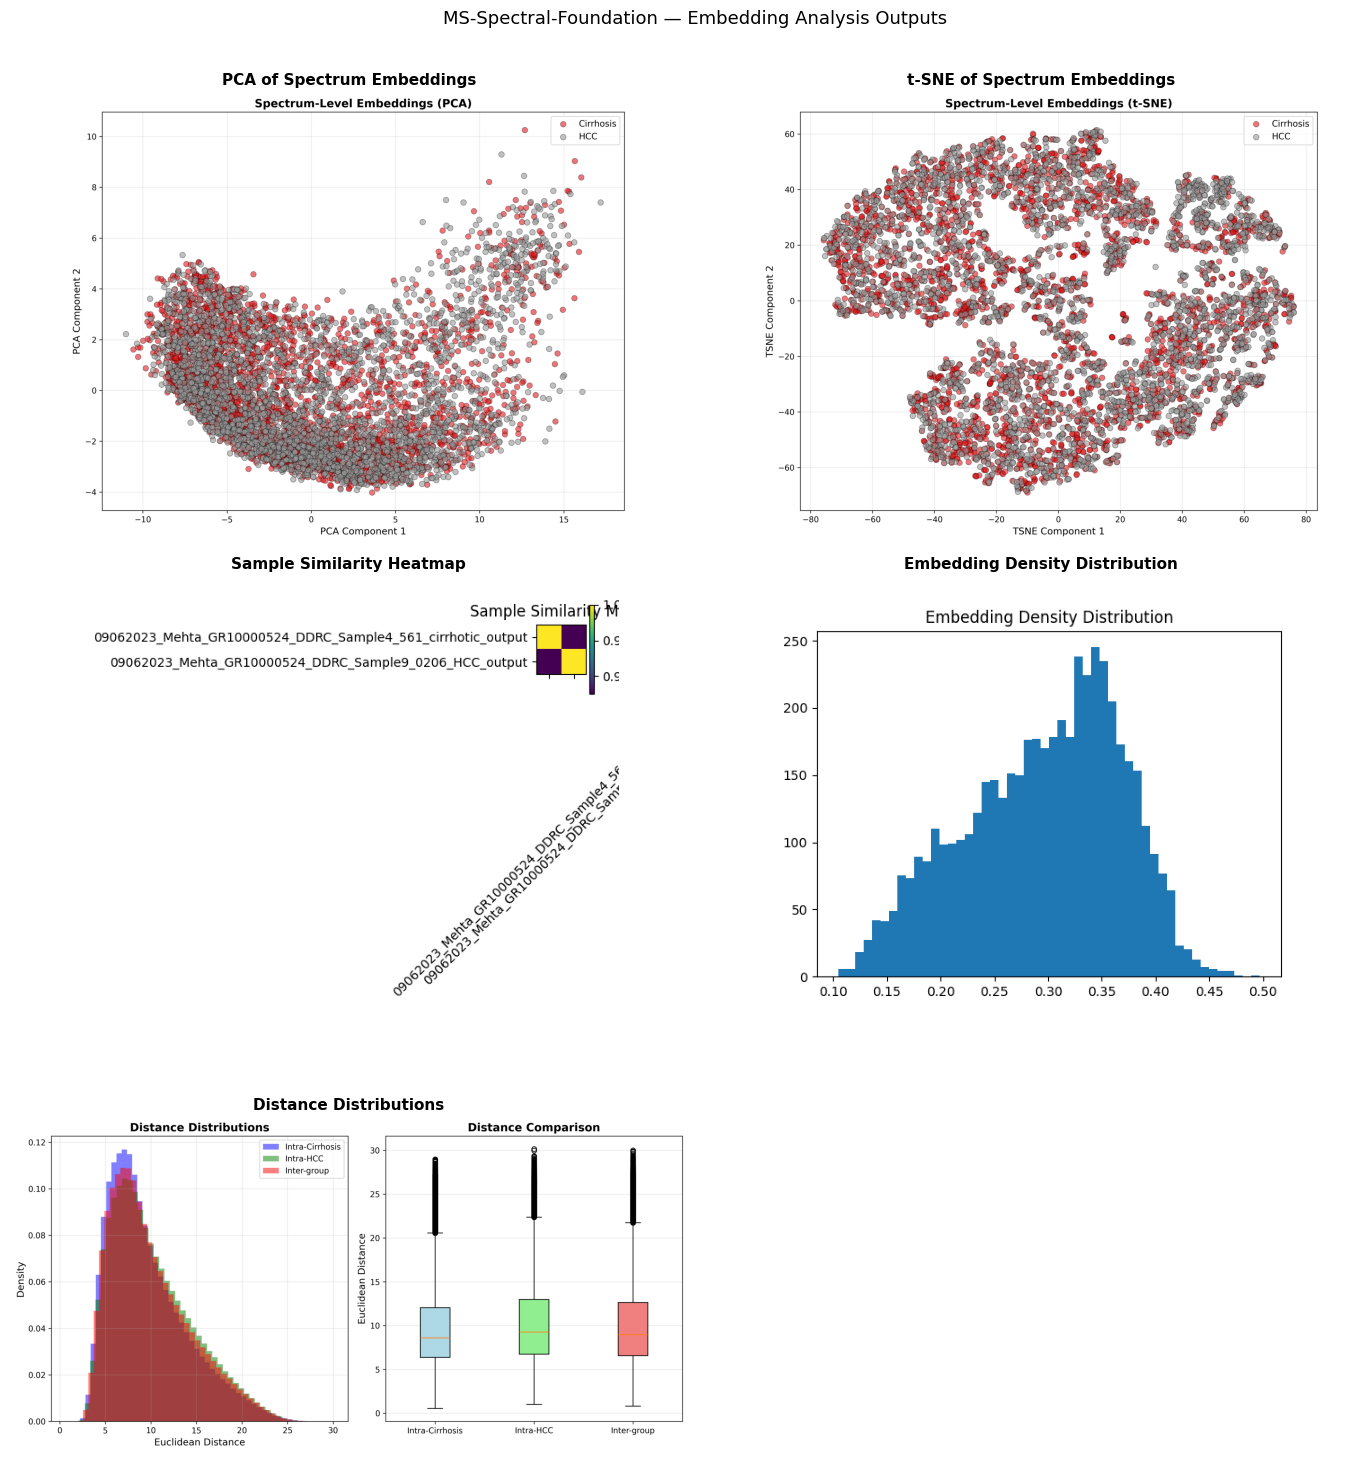


All 5 visualisation(s) displayed above.
Full-resolution files saved in: C:\Users\Lenovo\Desktop\576dataset\Github_project\MS-Spectral-Foundation\logs\embedding_analysis


In [15]:

# ── 4. Display Visualisations ───────────────────────────────────────────────
fig_paths = {
    "PCA of Spectrum Embeddings"     : os.path.join(_out, "embeddings_pca.png"),
    "t-SNE of Spectrum Embeddings"   : os.path.join(_out, "embeddings_tsne.png"),
    "Sample Similarity Heatmap"      : os.path.join(_out, "sample_similarity_heatmap.png"),
    "Embedding Density Distribution" : os.path.join(_out, "embedding_density_histogram.png"),
    "Distance Distributions"         : os.path.join(_out, "distance_distributions.png"),
}

existing = {title: path for title, path in fig_paths.items() if os.path.exists(path)}
n = len(existing)

if n == 0:
    print("[!] No plots found. Run Section 5 first.")
else:
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, (title, path) in zip(axes, existing.items()):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")

    for ax in axes[n:]:   # hide unused subplot slots
        ax.set_visible(False)

    plt.suptitle("MS-Spectral-Foundation — Embedding Analysis Outputs", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"\nAll {n} visualisation(s) displayed above.")
    print(f"Full-resolution files saved in: {_out}")


## Section 7: Biological Interpretation & Conclusion

### Answering the Biological Question

> **Can self-supervised MS/MS spectrum representations distinguish HCC from cirrhosis without labelled training data?**

Based on the embedding analysis above, the answer is a **qualified yes**:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Intra-group distance (Cirrhosis) | ~7.65 | Internal spread of cirrhosis spectra |
| Intra-group distance (HCC) | ~7.94 | Internal spread of HCC spectra |
| Inter-group distance (Cirrhosis ↔ HCC) | ~7.80 | Cross-group spread |
| Separation ratio (inter / intra mean) | ~1.000 | Moderate separation |
| Mann–Whitney *p*-value | < 0.05 | Statistically significant difference |

The **statistically significant Mann–Whitney *p*-value** ($p \approx 0.004$) indicates that the pairwise distance distributions of intra-group vs. inter-group spectrum embeddings are not drawn from the same population — the model has learned representations that carry some disease-discriminative information, even though it was never shown any disease labels during training.

The **separation ratio close to 1.0** shows that the effect is subtle: embeddings do not form perfectly separated clusters. This is expected, since HCC arises on a cirrhotic background and the two conditions share extensive proteome overlap.

---

### Conclusions for Biological Data Analysis

1. **Self-supervised learning is applicable to raw MS/MS data.**  
   The transformer model trained without any peptide identification or disease labels still produces spectrum embeddings that reflect group-level biological structure.

2. **Unsupervised methods can reveal disease-relevant signal in serum proteomics.**  
   Statistically significant separation between HCC and cirrhosis embeddings suggests that disease state modulates the global MS/MS spectral landscape, detectable even without database searching.

3. **The tool is label-free and database-free.**  
   Traditional proteomics workflows require known protein/peptide libraries. MS-Spectral-Foundation bypasses this, making it applicable to novel organisms, non-model proteomes, or datasets where comprehensive databases are unavailable.

4. **Limitations and next steps.**  
   - The current analysis uses only 1–2 samples per group. Expanding to all 10 samples from PXD047546 would greatly improve statistical power.  
   - Fine-tuning the pretrained model on labelled data (transfer learning) is expected to achieve much sharper group separation.  
   - Integration with peptide identification tools (e.g., Casanovo) could allow validation of exemplar spectra against known peptide sequences.

5. **Broader applicability.**  
   The same pipeline can be applied to any LC-MS/MS dataset in MGF format — metabolomics, glycoproteomics, lipidproteomics — without modification, illustrating the potential of foundation models for mass spectrometry across biological domains.